In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (10,5)

In [8]:
df= pd.read_csv('/content/Amazon Sale Report.csv')

/tmp/ipykernel_208/2288407378.py:1: DtypeWarning: Columns (21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('/content/Amazon Sale Report.csv')


In [11]:
df.shape

(76897, 24)

In [10]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76897 entries, 0 to 76896
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               76897 non-null  int64  
 1   Order ID            76897 non-null  object 
 2   Date                76896 non-null  object 
 3   Status              76896 non-null  object 
 4   Fulfilment          76896 non-null  object 
 5   Sales Channel       76896 non-null  object 
 6   ship-service-level  76896 non-null  object 
 7   Style               76896 non-null  object 
 8   SKU                 76896 non-null  object 
 9   Category            76896 non-null  object 
 10  Size                76896 non-null  object 
 11  ASIN                76896 non-null  object 
 12  Courier Status      72393 non-null  object 
 13  Qty                 76896 non-null  float64
 14  currency            72307 non-null  object 
 15  Amount              72307 non-null  float64
 16  ship

In [13]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,76897.000000,76896.000000,72307.000000,76876.000000
mean,38448.000000,0.901438,643.162790,463369.758936
std,22198.396162,0.321175,277.891449,193433.869876
min,0.000000,0.000000,0.000000,110001.000000
25%,19224.000000,1.000000,446.670000,380054.000000
50%,38448.000000,1.000000,599.000000,500028.000000
75%,57672.000000,1.000000,788.000000,600034.000000
max,76896.000000,15.000000,5584.000000,989898.000000


In [14]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,1
Status,1
Fulfilment,1
Sales Channel,1
ship-service-level,1
Style,1
SKU,1
Category,1


Handling nun values

In [16]:
df= df.drop(columns=["Unnamed: 22"])

In [17]:
df= df[df["Amount"].notna()]

In [21]:
df["currency"] =df["currency"].fillna("INR")

In [23]:
df["Courier Status"] =df["Courier Status"].fillna("Unknown")

In [24]:
df["promotion-ids"] =df["promotion-ids"].fillna("No Promotion")

In [26]:
df["fulfilled-by"] =df["fulfilled-by"].fillna("Merchant")

In [28]:
df=df.dropna(subset=["ship-city","ship-state","ship-postal-code","ship-country"])

In [29]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [30]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_208/936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [31]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Day"] = df["Date"].dt.day_name()

In [32]:
print("Total Revenue:", df["Amount"].sum())

print("Total Orders:", df["Order ID"].nunique())

Total Revenue: 46493774.83
Total Orders: 67512


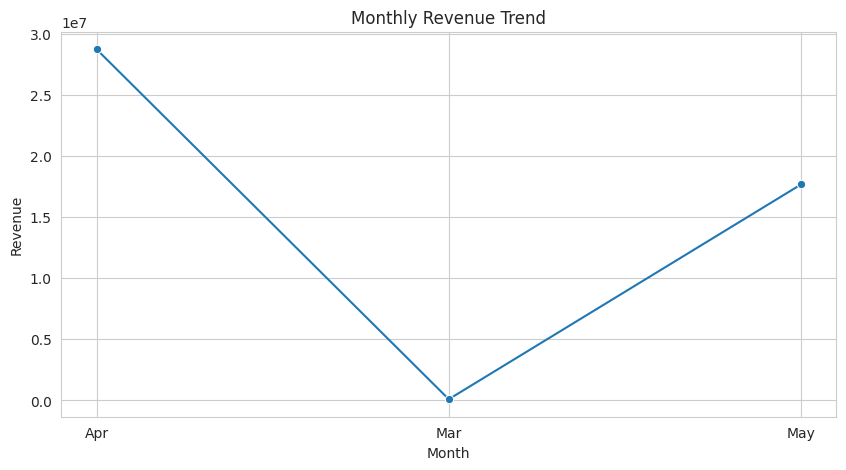

In [34]:
monthly_sales = df.groupby("Month_Name")["Amount"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="Month_Name", y="Amount", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

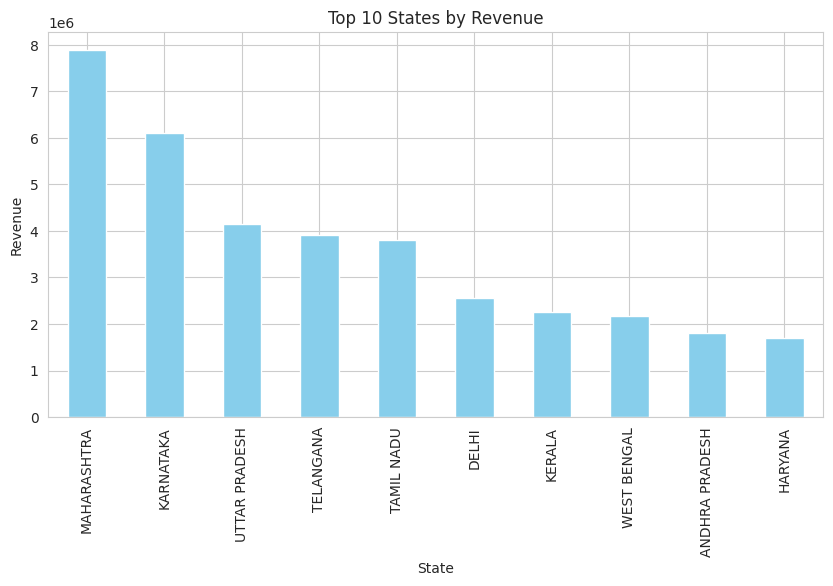

In [35]:
state_sales = (
    df.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sales.plot(kind="bar", color="skyblue")

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

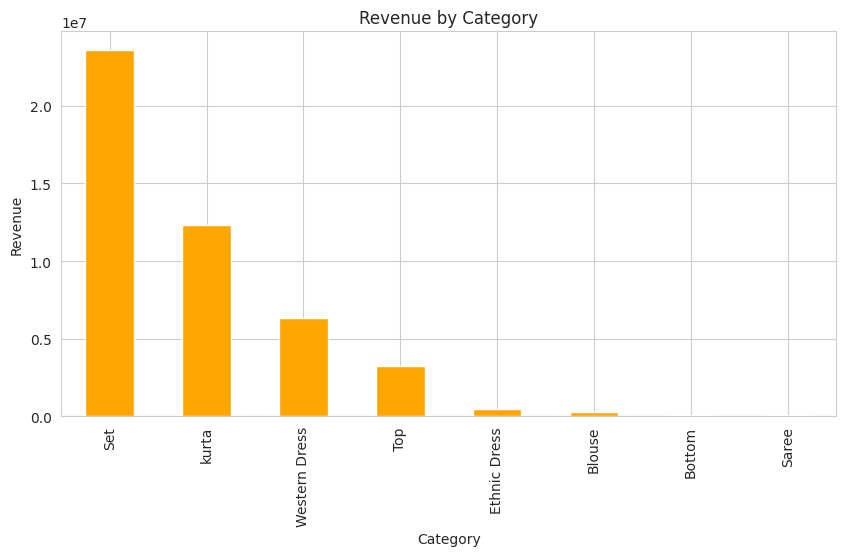

In [36]:
category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar", color="orange")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

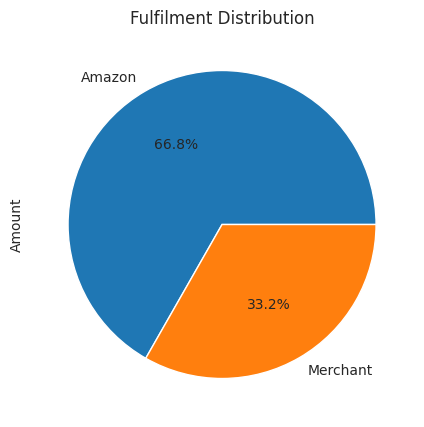

In [37]:
fulfilment_sales = df.groupby("Fulfilment")["Amount"].sum()

fulfilment_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Fulfilment Distribution")

plt.show()

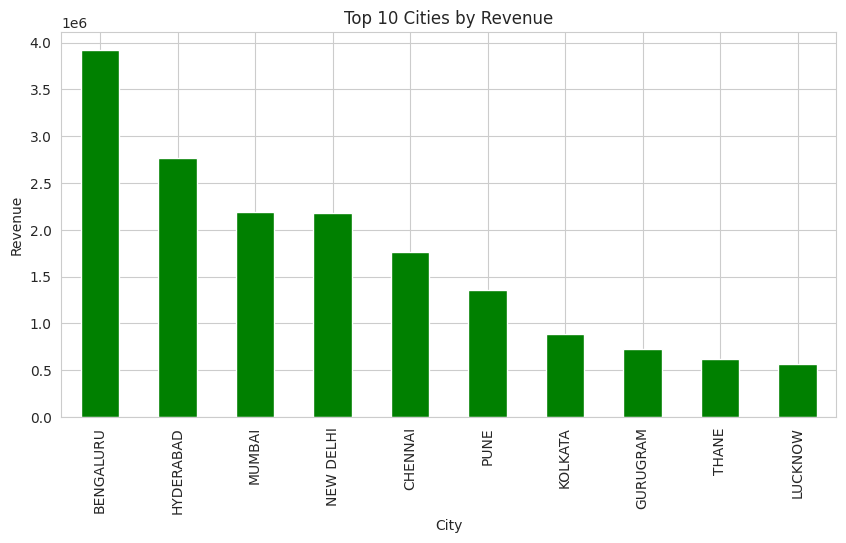

In [38]:
city_sales = (
    df.groupby("ship-city")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

city_sales.plot(kind="bar", color="green")

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

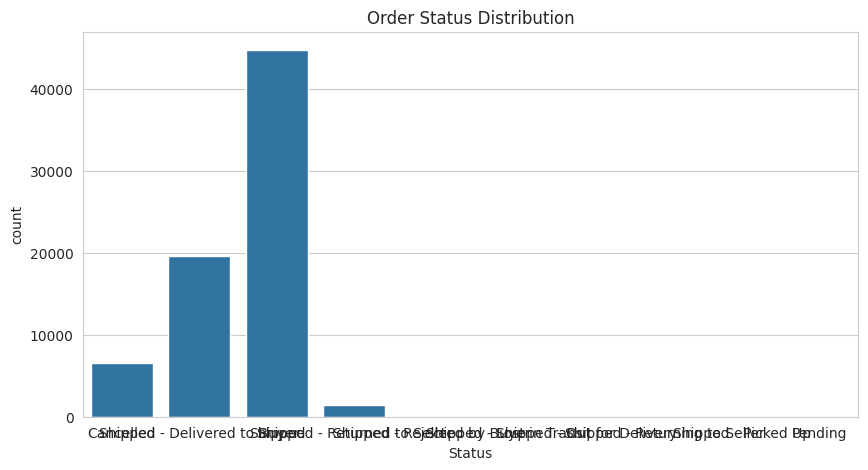

In [39]:
sns.countplot(data=df, x="Status")

plt.title("Order Status Distribution")

plt.show()

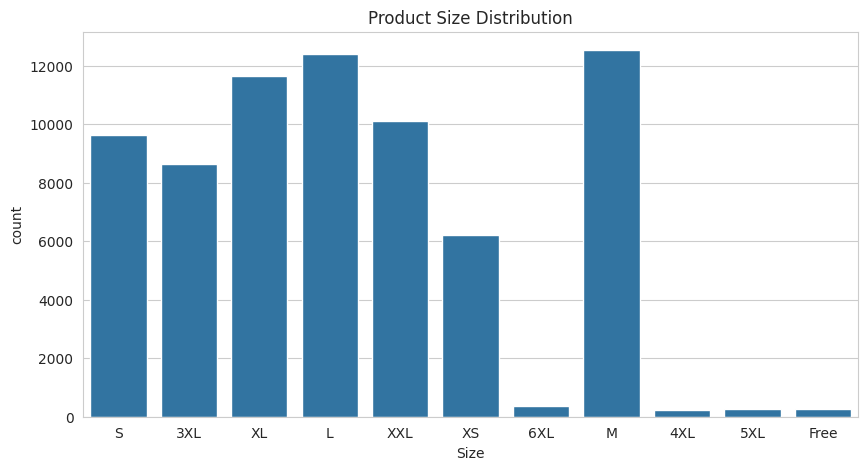

In [40]:
sns.countplot(data=df, x="Size")

plt.title("Product Size Distribution")

plt.show()

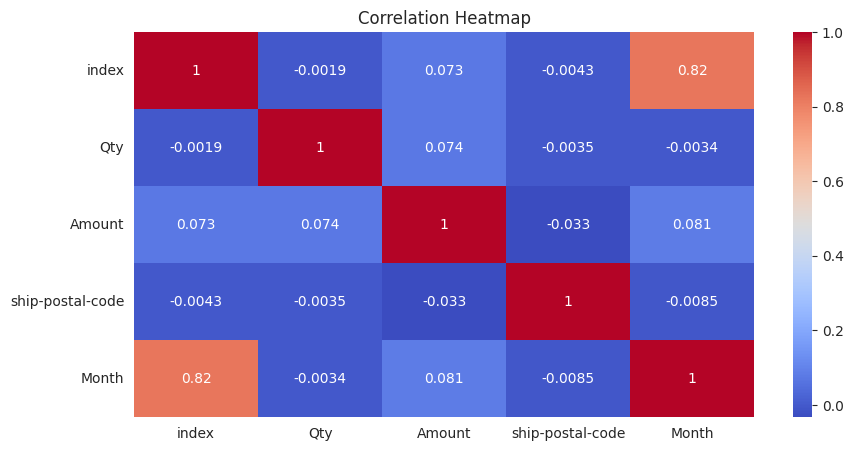

In [42]:

numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

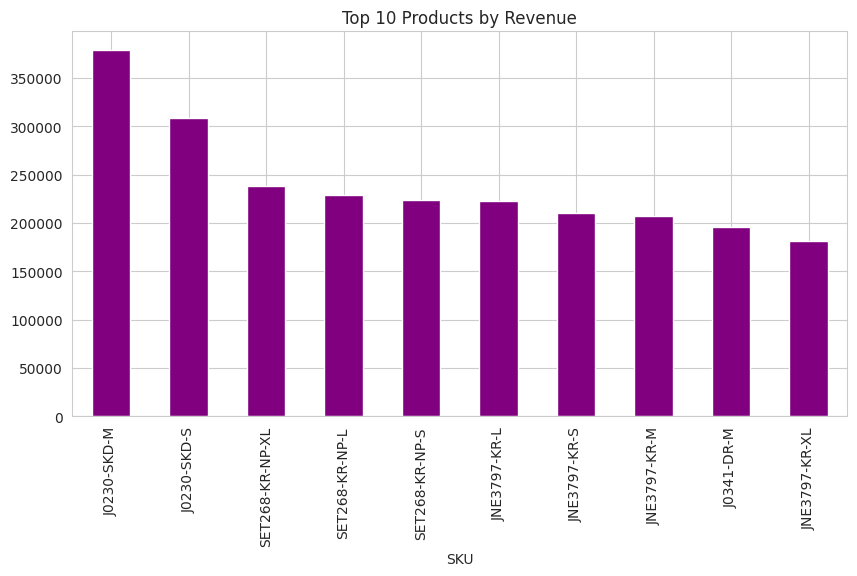

In [43]:
sku_sales = (
    df.groupby("SKU")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sku_sales.plot(kind="bar", color="purple")

plt.title("Top 10 Products by Revenue")

plt.show()

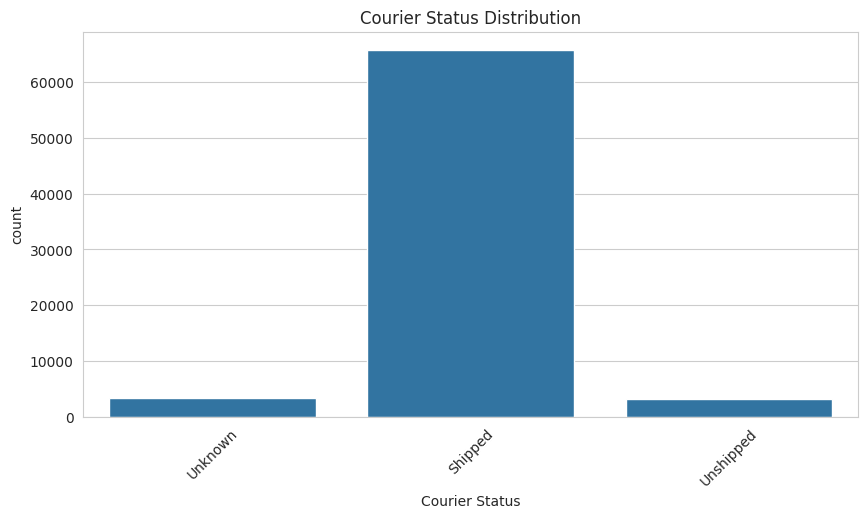

In [44]:
sns.countplot(data=df, x="Courier Status")

plt.title("Courier Status Distribution")

plt.xticks(rotation=45)

plt.show()